<a href="https://colab.research.google.com/github/subhammalla6-rgb/Employee-Data-EDA/blob/main/project_EDA_emp_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
df = pd.read_csv('Messy_Employee_dataset.csv')
df.head(10)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
5,EMP1005,Alice,Garcia,40.0,Sales-Texas,Inactive,6/10/2020,88642.84,alice.garcia@example.com,-5409003485,Good,False
6,EMP1006,Frank,Jones,NaN,Admin-Nevada,Active,4/3/2020,96288.43,frank.jones@example.com,-4518376063,Good,False
7,EMP1007,Bob,Jones,30.0,Cloud Tech-Florida,Inactive,7/17/2022,94497.91,bob.jones@example.com,-4134327559,Average,True
8,EMP1008,Frank,Davis,35.0,Admin-Nevada,Inactive,12/8/2023,115565.82,frank.davis@example.com,-4177656123,Excellent,True
9,EMP1009,Charlie,Johnson,NaN,DevOps-New York,Active,8/4/2022,76561.88,charlie.johnson@example.com,-8156985699,Excellent,True


In [51]:
# Numerical statistics (Salary, Age, Phone)
print("--- Numerical Summary ---")
display(df.describe())

# Categorical statistics (Department, Status, Performance)
print("\n--- Categorical Summary ---")
display(df.describe(include=['O']))

--- Numerical Summary ---


,Age,Salary,Phone
count,809.000000,996.000000,1.020000e+03
mean,32.484549,85155.056396,-4.942253e+09
std,5.656860,19873.727918,2.817326e+09
min,25.000000,50047.320000,-9.994973e+09
25%,25.000000,68392.487500,-7.341992e+09
50%,30.000000,85547.870000,-4.943997e+09
75%,40.000000,100974.027500,-2.520391e+09
max,40.000000,119971.650000,-3.896086e+06



--- Categorical Summary ---


,Employee_ID,First_Name,Last_Name,Department_Region,Status,Join_Date,Email,Performance_Score
count,1020,1020,1020,1020,1020,1020,1020,1020
unique,1020,8,8,36,3,760,64,4
top,EMP2019,Frank,Brown,HR-Florida,Pending,6/10/2024,grace.brown@example.com,Good
freq,1,142,148,41,356,5,27,270


In [52]:
df.columns

Index(['Employee_ID', 'First_Name', 'Last_Name', 'Age', 'Department_Region',
       'Status', 'Join_Date', 'Salary', 'Email', 'Phone', 'Performance_Score',
       'Remote_Work'],
      dtype='object')

In [53]:
df.columns = df.columns.str.strip().str.lower()

In [54]:
df['phone'] = df['phone'].astype(str)
print(df['phone'].dtype)

object


In [55]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'department_region',
       'status', 'join_date', 'salary', 'email', 'phone', 'performance_score',
       'remote_work'],
      dtype='object')

In [56]:
df[['department', 'region']] = df['department_region'].str.split('-', expand=True)
df.drop(columns=['department_region'], inplace=True)

In [57]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'status', 'join_date',
       'salary', 'email', 'phone', 'performance_score', 'remote_work',
       'department', 'region'],
      dtype='object')

In [58]:
# 1. Convert salary to numeric
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

# 2. REMOVE OUTLIERS NOW (This fixes all future graphs: Histogram, Bar Chart, etc.)
# We keep only realistic salaries and remove the 'phone numbers'
df = df[(df['salary'] > 10000) & (df['salary'] < 300000)].copy()

# 3. Handle Age
df['age'] = df['age'].fillna(df['age'].median())
df.age

,age
0,25.0
1,30.0
2,30.0
3,25.0
4,25.0
...,...
1014,30.0
1016,30.0
1017,40.0
1018,30.0


In [59]:
df.salary

,salary
0,59767.65
1,65304.66
2,88145.90
3,69450.99
4,109324.61
...,...
1014,51990.98
1016,100215.06
1017,114587.11
1018,71318.79


In [60]:
df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')
df.join_date

,join_date
0,2021-04-02
1,2020-07-10
2,2023-12-07
3,2021-11-27
4,2022-01-05
...,...
1014,2021-05-16
1016,2021-11-07
1017,2023-10-04
1018,2024-12-16


In [61]:
df['status'] = df['status'].str.strip().str.capitalize()
df['performance_score'] = df['performance_score'].str.strip().str.capitalize()

In [62]:
df.status

,status
0,Active
1,Active
2,Pending
3,Inactive
4,Active
...,...
1014,Pending
1016,Inactive
1017,Active
1018,Inactive


In [63]:
df.performance_score

,performance_score
0,Average
1,Excellent
2,Good
3,Good
4,Poor
...,...
1014,Excellent
1016,Good
1017,Average
1018,Good


In [64]:
df = df.drop_duplicates()

In [65]:
df.to_csv('Cleaned_Employee_Data.csv', index=False)

print(" Data Cleaning Complete!")
print(f"Final shape: {df.shape}")
df.head()

 Data Cleaning Complete!
Final shape: (996, 13)


,employee_id,first_name,last_name,age,status,join_date,salary,email,phone,performance_score,remote_work,department,region
0,EMP1000,Bob,Davis,25.0,Active,2021-04-02,59767.65,bob.davis@example.com,-1651623197,Average,True,DevOps,California
1,EMP1001,Bob,Brown,30.0,Active,2020-07-10,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Finance,Texas
2,EMP1002,Alice,Jones,30.0,Pending,2023-12-07,88145.90,alice.jones@example.com,-5596363211,Good,True,Admin,Nevada
3,EMP1003,Eva,Davis,25.0,Inactive,2021-11-27,69450.99,eva.davis@example.com,-3476490784,Good,True,Admin,Nevada
4,EMP1004,Frank,Williams,25.0,Active,2022-01-05,109324.61,frank.williams@example.com,-1586734256,Poor,False,Cloud Tech,Florida


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")

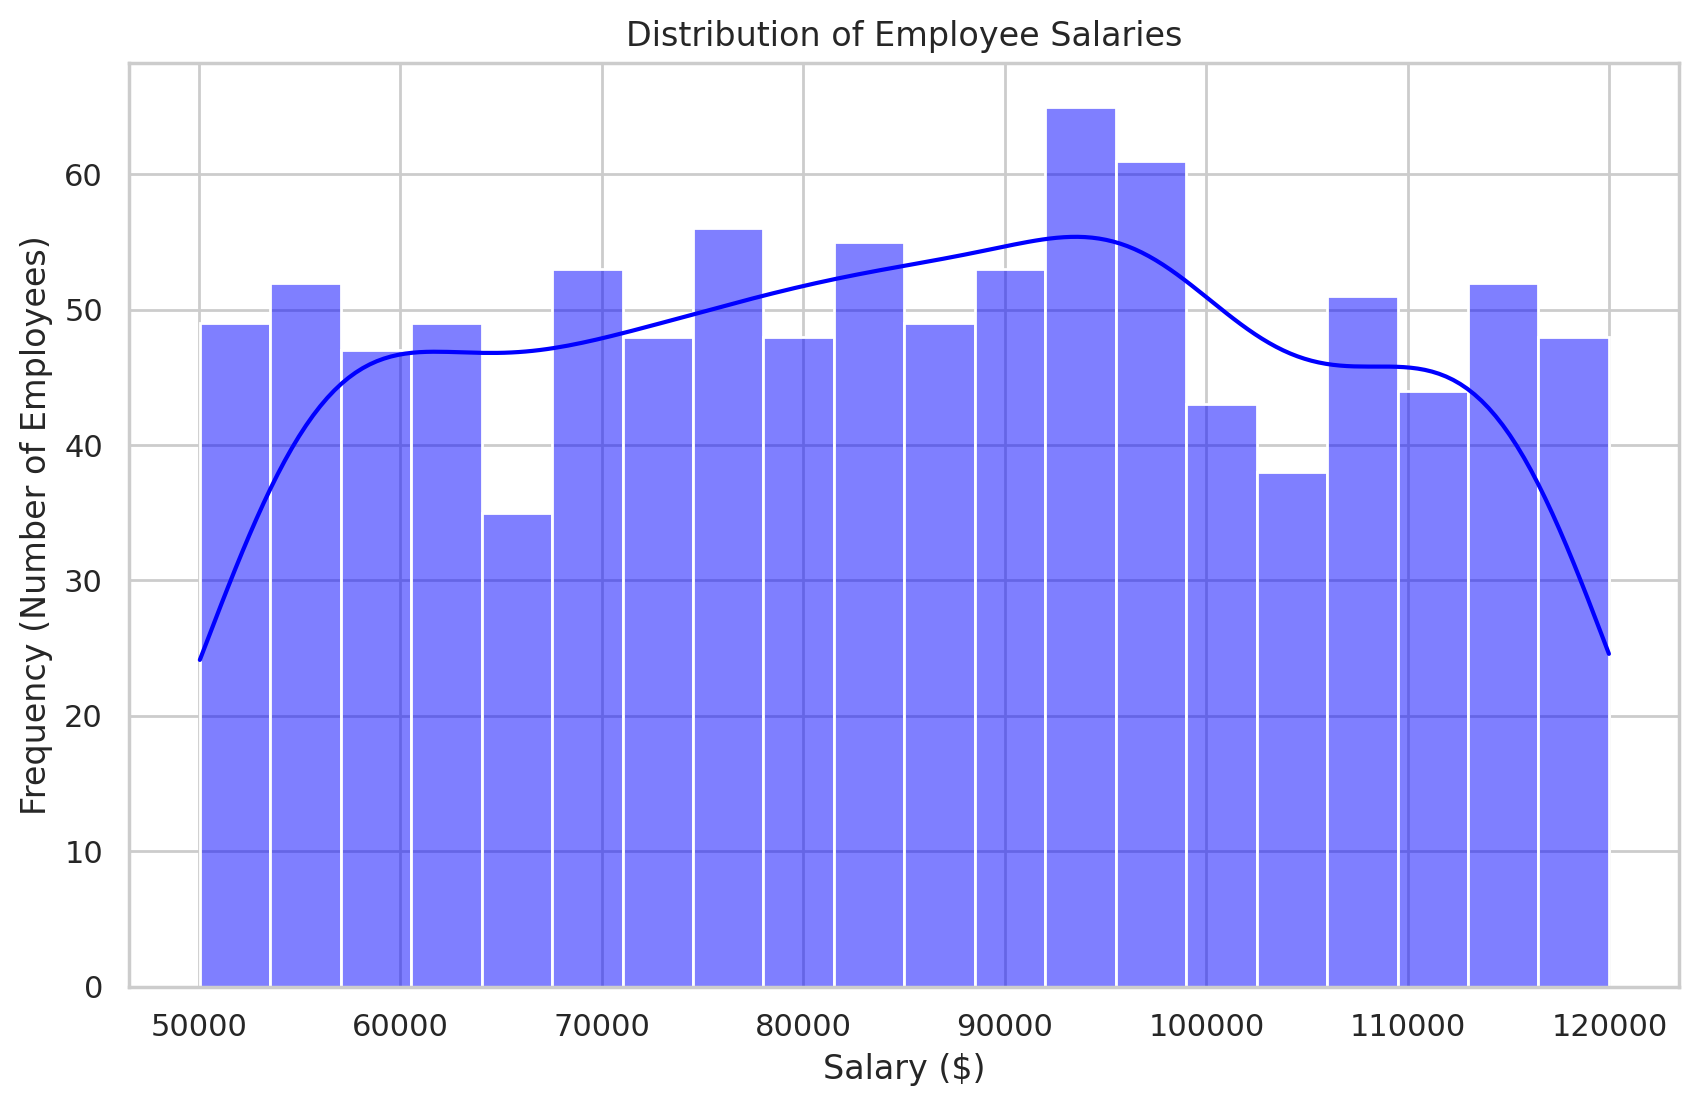

In [67]:
plt.figure(figsize=(10, 6))
# This single line handles the bars (hist) and the smooth line (kde)
sns.histplot(df['salary'], kde=True, color='blue', bins=20)

plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency (Number of Employees)')
plt.show()

/tmp/ipykernel_1547/1605789697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=dept_salary, x='department', y='salary', palette='viridis')


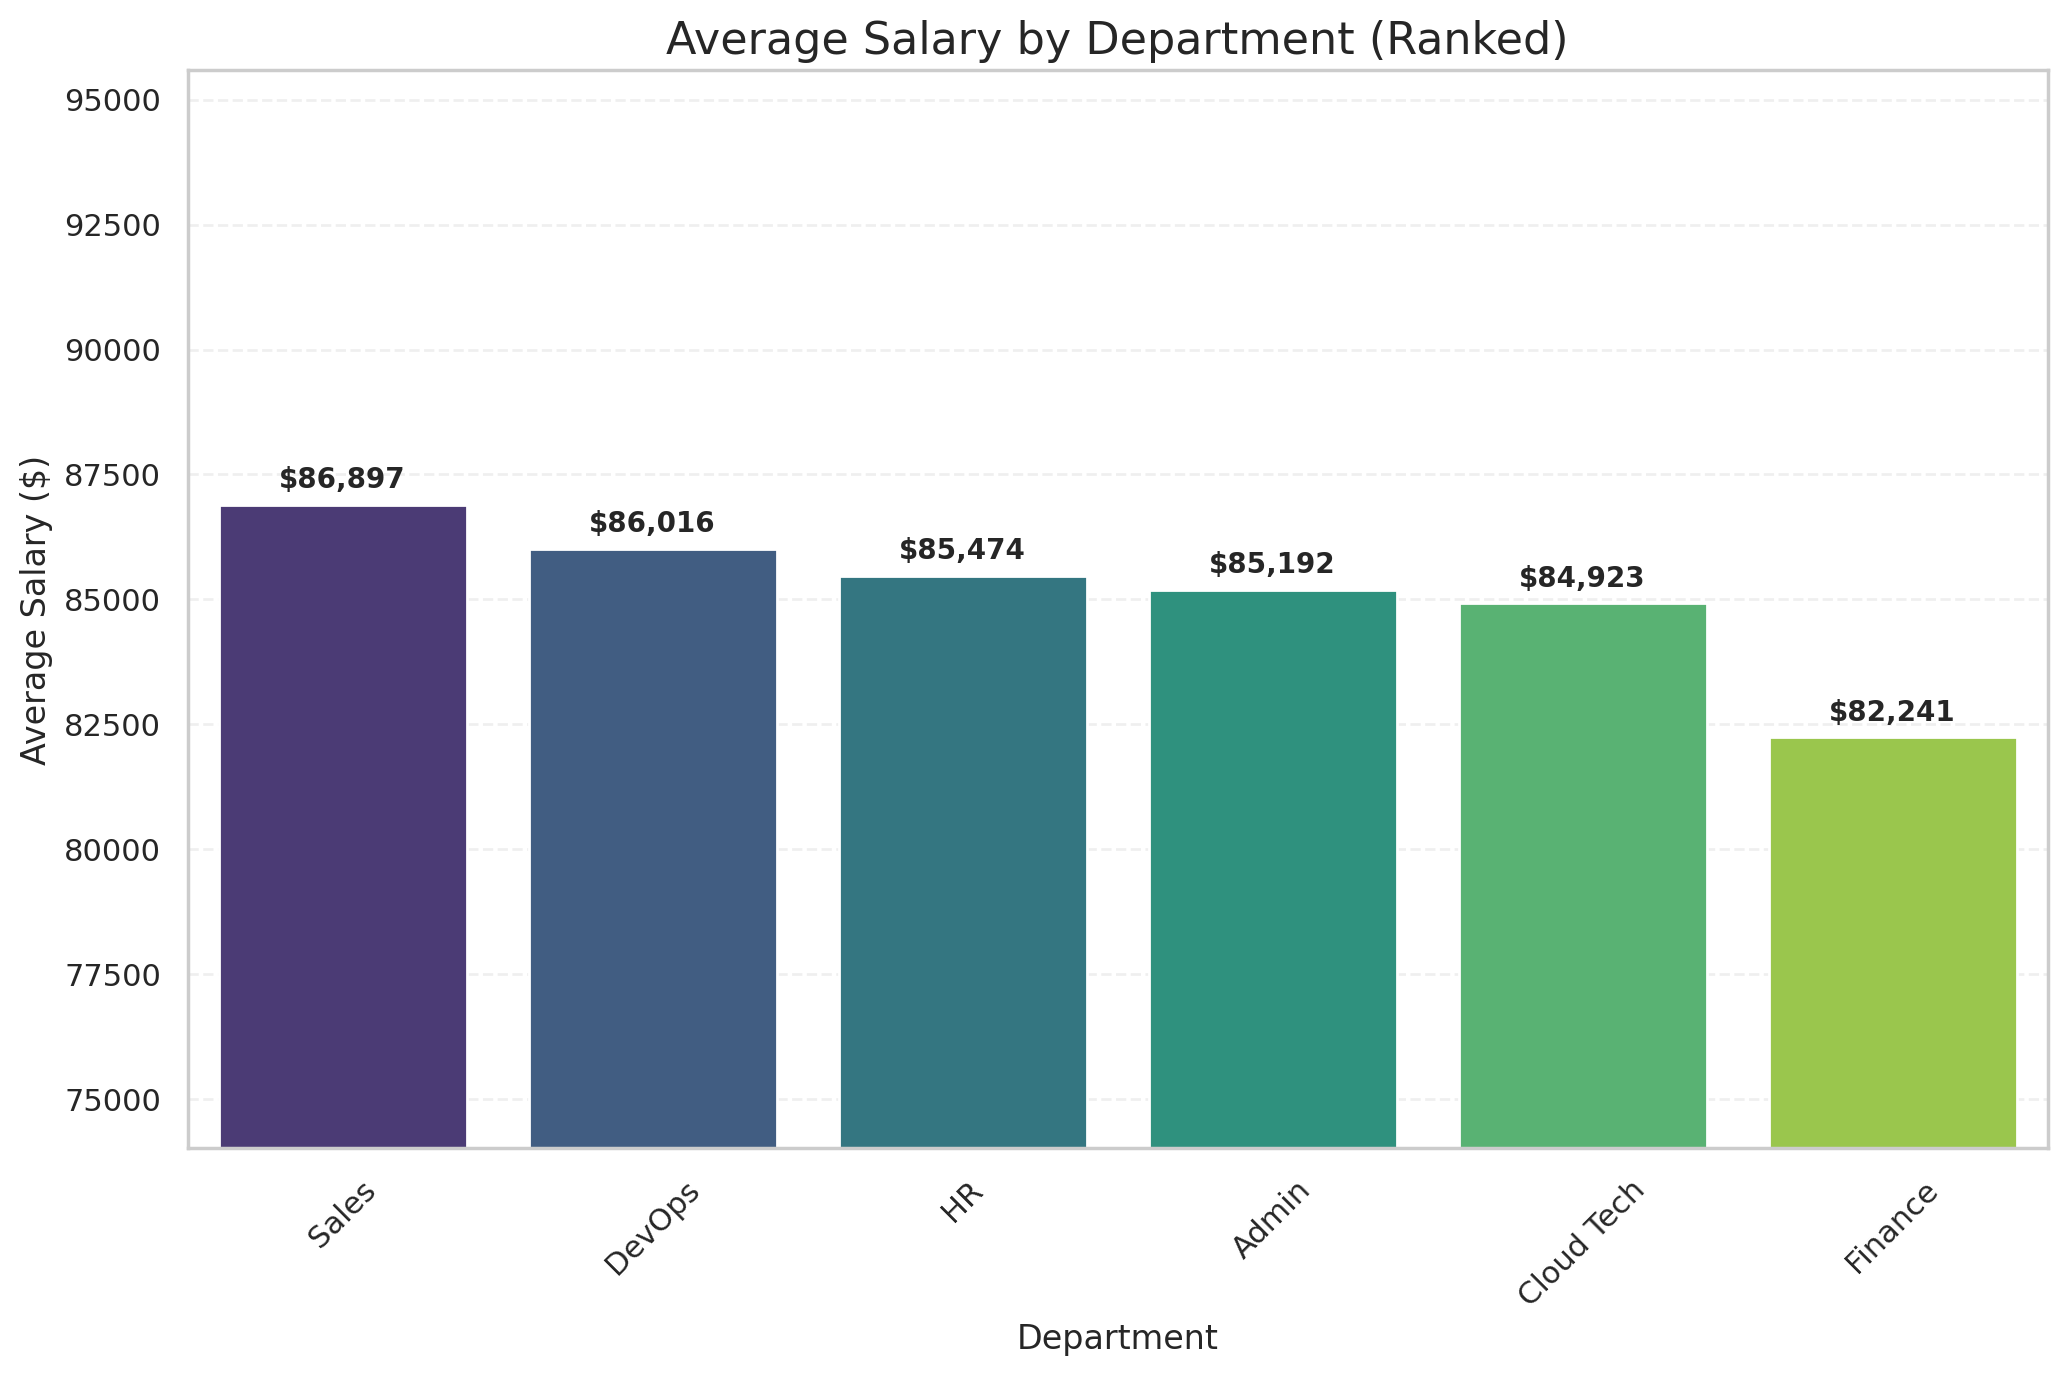

In [68]:
# 1. Calculate the mean salary per department and sort it
dept_salary = df.groupby('department')['salary'].mean().sort_values(ascending=False).reset_index()

# 2. Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=dept_salary, x='department', y='salary', palette='viridis')

# 3. Add exact value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

# 4. Zoom in the Y-axis slightly to show the difference
# We set the bottom to 10% less than the minimum salary
min_sal = dept_salary['salary'].min()
plt.ylim(min_sal * 0.9, dept_salary['salary'].max() * 1.1)
#Note: Y-axis is scaled to highlight the salary differences between departments."
# 5. Final Styling
plt.title('Average Salary by Department (Ranked)', fontsize=16)
plt.ylabel('Average Salary ($)')
plt.xlabel('Department')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

/tmp/ipykernel_1547/3748586658.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index('join_date').resample('M').size().plot(color='green', marker='o')


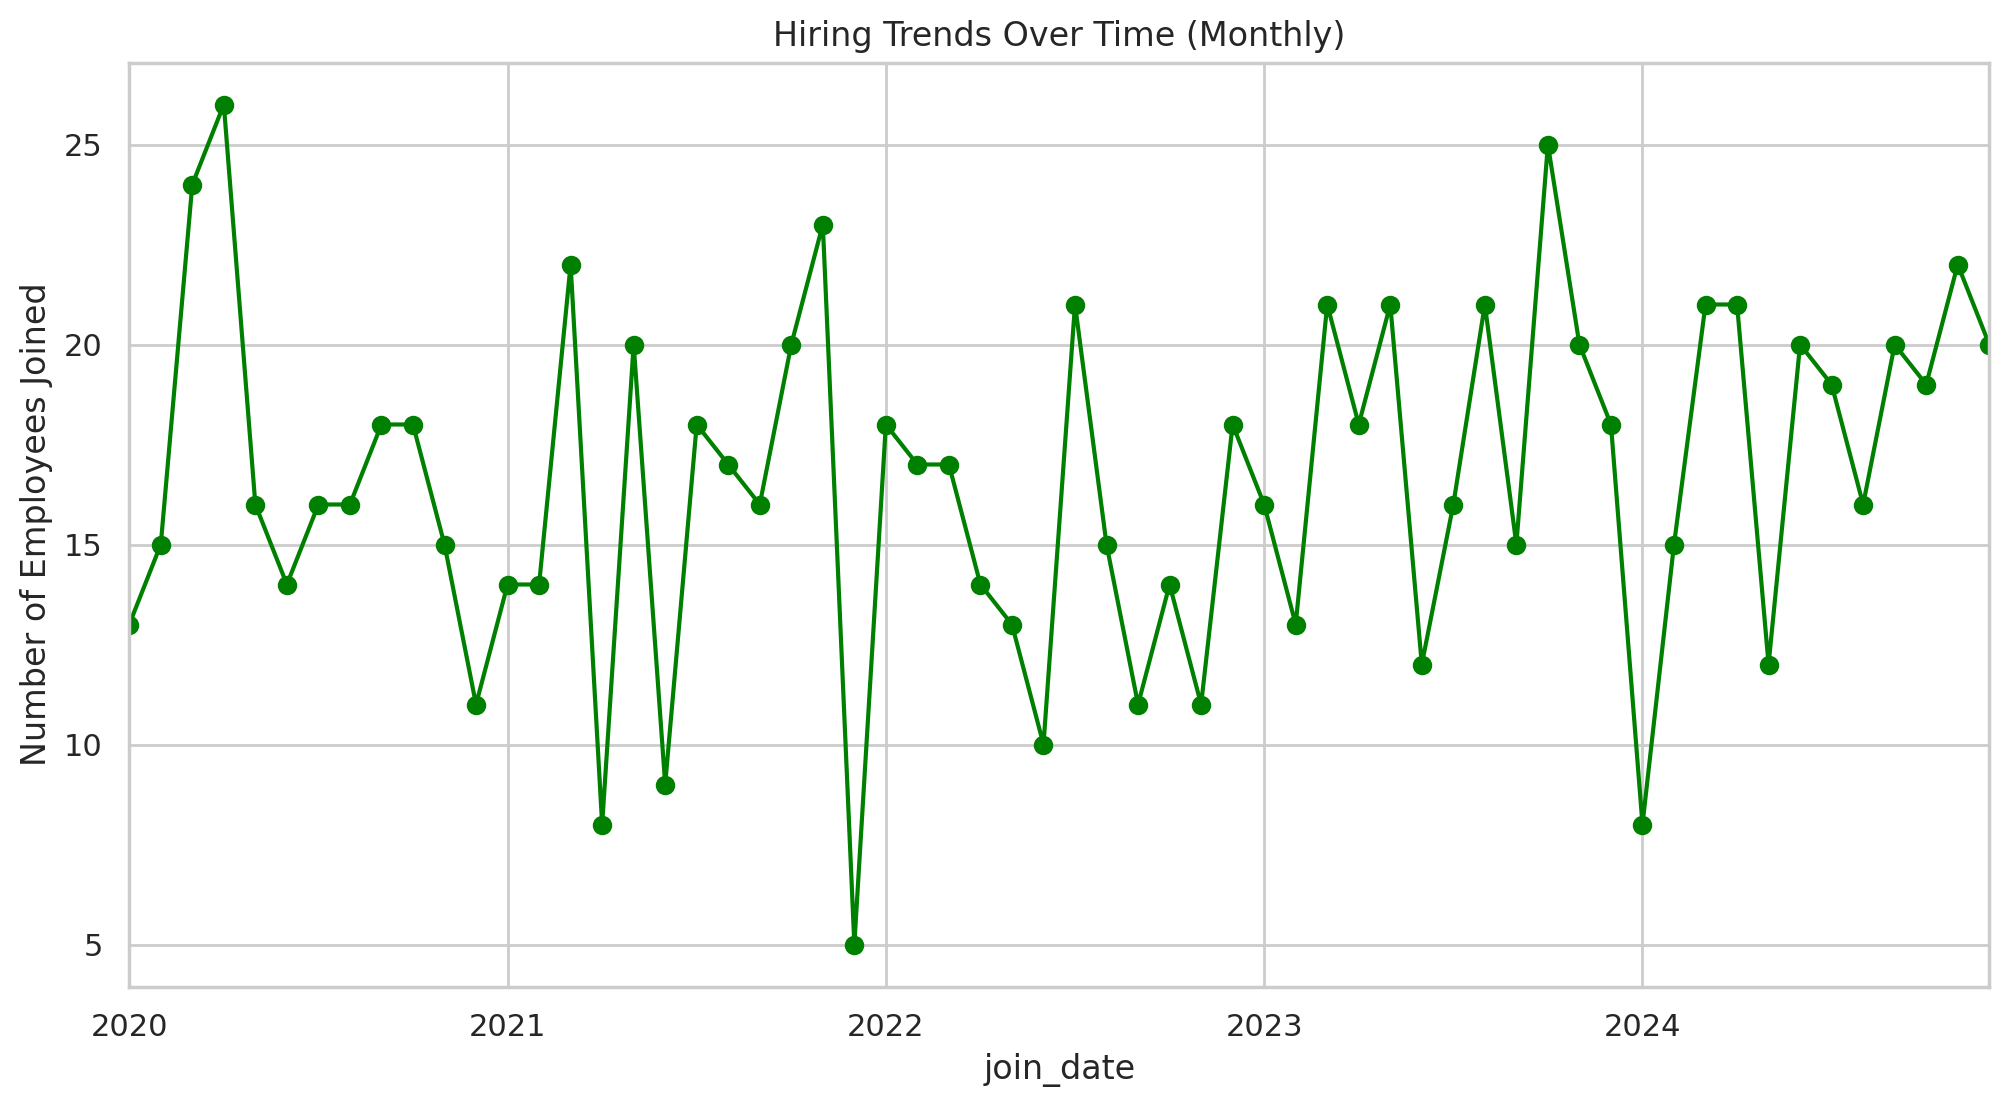

In [69]:
plt.figure(figsize=(12, 6))
# Resampling by month ('M') and counting entries
df.set_index('join_date').resample('M').size().plot(color='green', marker='o')
plt.title('Hiring Trends Over Time (Monthly)')
plt.ylabel('Number of Employees Joined')
plt.grid(True)
plt.show()

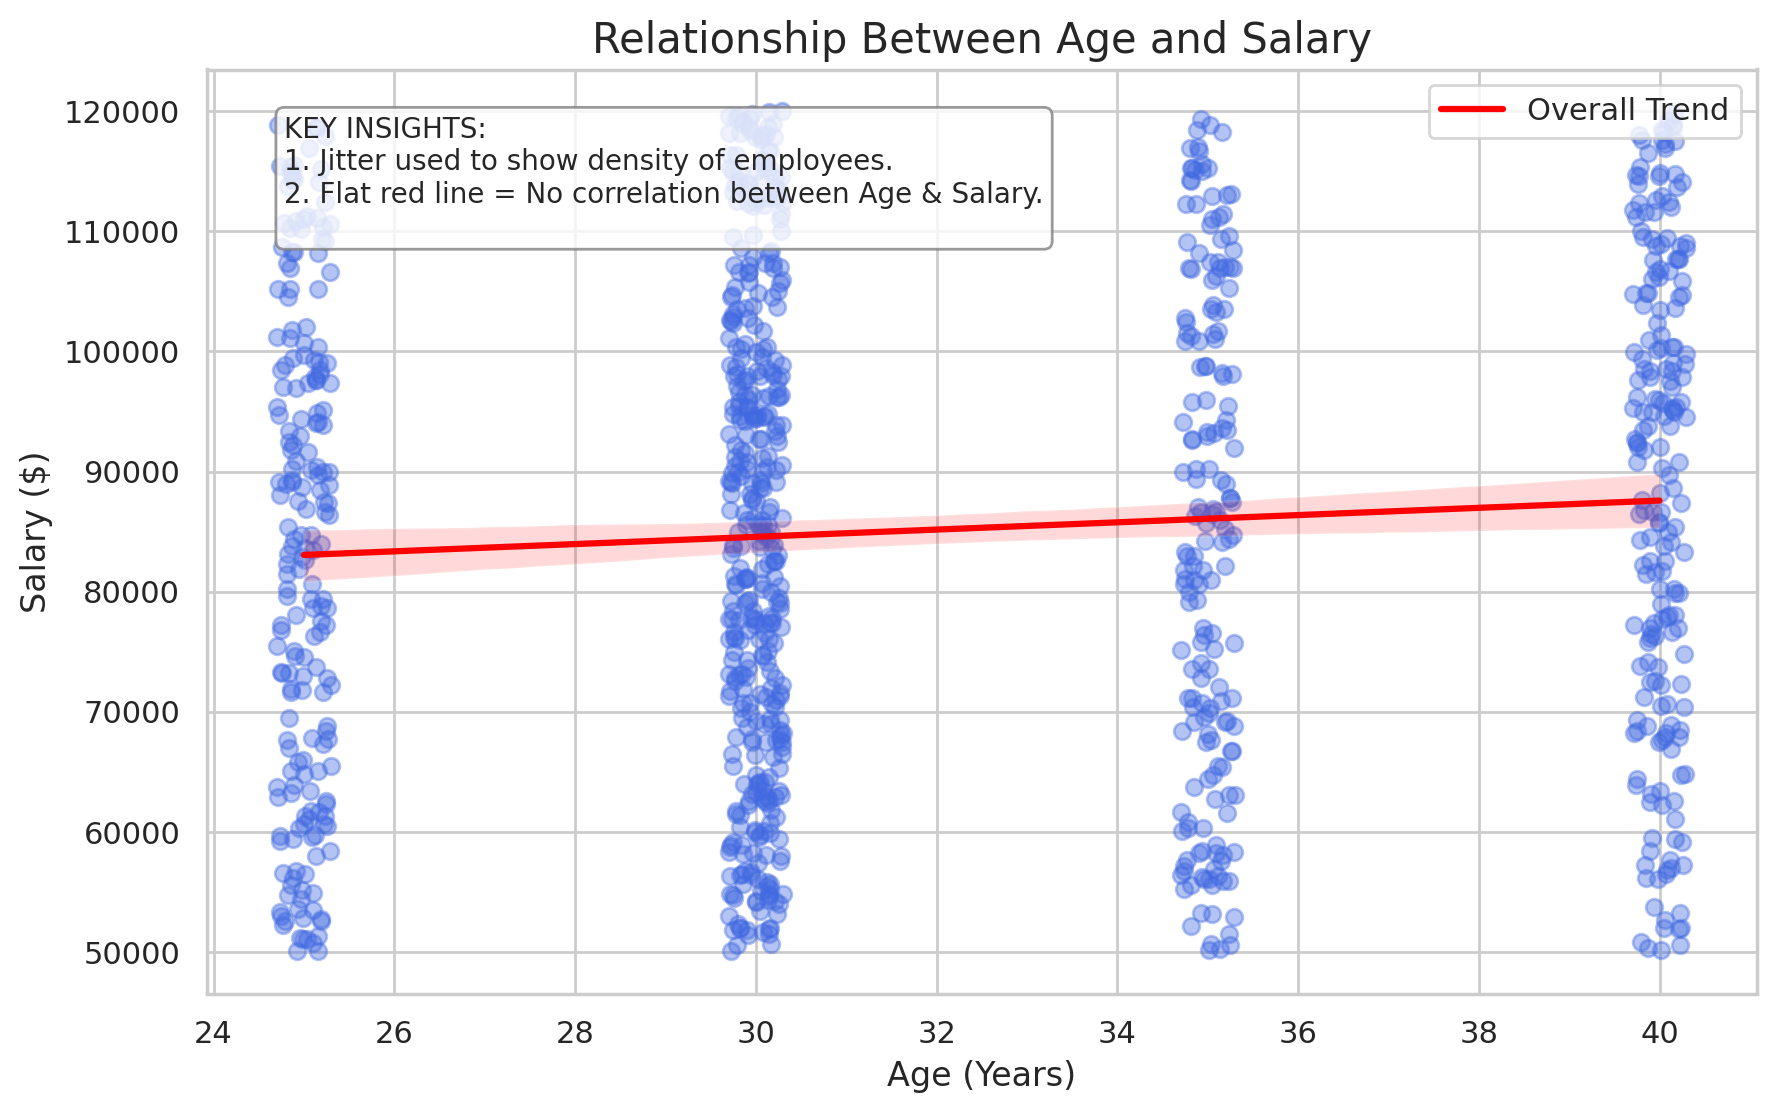

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter and Plot
df_plot = df[(df['salary'] > 10000) & (df['salary'] < 300000)].copy()
plt.figure(figsize=(10, 6))

sns.regplot(data=df_plot, x='age', y='salary',
            x_jitter=0.3,
            scatter_kws={'alpha':0.4, 'color':'royalblue'},
            line_kws={'color':'red', 'label':'Overall Trend'})

# ADDING THE TEXT BOX EXPLANATION
explanation_text = (
    "KEY INSIGHTS:\n"
    "1. Jitter used to show density of employees.\n"
    "2. Flat red line = No correlation between Age & Salary.\n"

)

# Position the box in the top-left corner
plt.gca().text(0.05, 0.95, explanation_text, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.title('Relationship Between Age and Salary', fontsize=15)
plt.xlabel('Age (Years)')
plt.ylabel('Salary ($)')
plt.legend(loc='upper right')
plt.show()

In [71]:
df.to_csv('Cleaned_Employee_Data.csv', index=False)

# To download it directly to your computer:
from google.colab import files
files.download('Cleaned_Employee_Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>